# Used Car Price Prediction — Gradient Boosting Benchmark

**Author:** Dr. Danisha L. Thomas, PhD | Clinical Psychology | Data Science  
**Project:** Sprint 12 — Numerical Methods  
**Tools:** Python 3 · Pandas · Scikit-learn · LightGBM · CatBoost · XGBoost · Matplotlib

**Objective:** Build a used car price prediction model for Rusty Bargain's customer-facing app. The business requires both **prediction quality** (RMSE) and **prediction speed** (inference time). Five models are trained and benchmarked: Linear Regression (baseline), Random Forest, LightGBM, CatBoost, and XGBoost — with the best model recommended based on the quality/speed tradeoff.

---

# Data Preprocessing & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - preprocessing & evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Machine learning models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor
import xgboost as xgb

# Time tracking
import time

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline

df = pd.read_csv('/datasets/car_data.csv')

# Initial data exploration
print("Dataset shape:", df.shape)
print("\n" + "="*50)
display(df.head())
print("\n" + "="*50)
print("Data types and missing values:")
display(df.info())
print("\n" + "="*50)
print("Basic statistics:")
display(df.describe())

Dataset shape: (354369, 16)



,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17



Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  

None


Basic statistics:


,Price,RegistrationYear,Power,Mileage,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


In [2]:
# Drop column that has all zeros
df = df.drop('NumberOfPictures', axis=1)

# Verify the column was dropped
print("Columns after dropping NumberOfPictures:")
print(df.columns.tolist())
print(f"\nNew shape: {df.shape}")

# Remove outliers
print("Shape before outlier removal:", df.shape)

# Remove cars with unrealistic prices
df = df[df['Price'] > 0]

# Remove cars with unrealistic reg years
df = df[(df['RegistrationYear'] >= 1900) & (df['RegistrationYear'] <= 2016)]

# Remove cars with unrealistic power values
df = df[(df['Power'] > 0) & (df['Power'] <= 500)]

print("Shape after outlier removal:", df.shape)
print(f"Removed {354369 - len(df)} rows")

Columns after dropping NumberOfPictures:
['DateCrawled', 'Price', 'VehicleType', 'RegistrationYear', 'Gearbox', 'Power', 'Model', 'Mileage', 'RegistrationMonth', 'FuelType', 'Brand', 'NotRepaired', 'DateCreated', 'PostalCode', 'LastSeen']

New shape: (354369, 15)
Shape before outlier removal: (354369, 15)
Shape after outlier removal: (296505, 15)
Removed 57864 rows


In [3]:
# Check the ranges of cleaned data
print("Price range:", df['Price'].min(), "to", df['Price'].max())
print("Registration year range:", df['RegistrationYear'].min(), "to", df['RegistrationYear'].max())
print("Power range:", df['Power'].min(), "to", df['Power'].max())

Price range: 1 to 20000
Registration year range: 1910 to 2016
Power range: 1 to 500


In [4]:
# Check missing values after outlier removal
print("Missing values per column:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Percentage of missing values:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values per column:
DateCrawled              0
Price                    0
VehicleType          11043
RegistrationYear         0
Gearbox               5384
Power                    0
Model                11195
Mileage                  0
RegistrationMonth        0
FuelType             15567
Brand                    0
NotRepaired          42940
DateCreated              0
PostalCode               0
LastSeen                 0
dtype: int64

Percentage of missing values:
DateCrawled           0.00
Price                 0.00
VehicleType           3.72
RegistrationYear      0.00
Gearbox               1.82
Power                 0.00
Model                 3.78
Mileage               0.00
RegistrationMonth     0.00
FuelType              5.25
Brand                 0.00
NotRepaired          14.48
DateCreated           0.00
PostalCode            0.00
LastSeen              0.00
dtype: float64


In [5]:
# Handle missing values in categorical columns
print("Filling missing categorical values with 'unknown'")

categorical_columns = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'NotRepaired']

for col in categorical_columns:
    df[col].fillna('unknown', inplace=True)

# Verify no missing values remain
print("\nMissing values after filling:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Filling missing categorical values with 'unknown'

Missing values after filling:
DateCrawled          0
Price                0
VehicleType          0
RegistrationYear     0
Gearbox              0
Power                0
Model                0
Mileage              0
RegistrationMonth    0
FuelType             0
Brand                0
NotRepaired          0
DateCreated          0
PostalCode           0
LastSeen             0
dtype: int64

Total missing values: 0


In [6]:
# Check data columns
print("Data columns:")
print(df[['DateCrawled', 'DateCreated', 'LastSeen']].head())

Data columns:
        DateCrawled       DateCreated          LastSeen
1  24/03/2016 10:58  24/03/2016 00:00  07/04/2016 01:46
2  14/03/2016 12:52  14/03/2016 00:00  05/04/2016 12:47
3  17/03/2016 16:54  17/03/2016 00:00  17/03/2016 17:40
4  31/03/2016 17:25  31/03/2016 00:00  06/04/2016 10:17
5  04/04/2016 17:36  04/04/2016 00:00  06/04/2016 19:17


In [7]:
# Drop date columns - not useful for price predictions
df = df.drop(['DateCrawled', 'DateCreated', 'LastSeen'], axis=1)
print("Remaining Colums:", df.columns.tolist())

Remaining Colums: ['Price', 'VehicleType', 'RegistrationYear', 'Gearbox', 'Power', 'Model', 'Mileage', 'RegistrationMonth', 'FuelType', 'Brand', 'NotRepaired', 'PostalCode']


In [8]:
# Create encoded version for models that need OHE (Linear Regression, Random Forest, XGBoost)
df_encoded = pd.get_dummies(df, columns=['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'NotRepaired'])

# Create categorical version for models that handle categories (LightGBM, CatBoost)
df_categorical = df.copy()

print("Encoded version shape:", df_encoded.shape)
print("Categorical version shape:", df_categorical.shape)

Encoded version shape: (296505, 319)
Categorical version shape: (296505, 12)


### Encoding Strategy and High-Cardinality Features

**Two-Dataset Approach:**
I created two versions of the dataset to accommodate different model requirements:
- **Encoded version (`df_encoded`)**: One-hot encoding for scikit-learn models (Linear Regression, Random Forest, XGBoost)
- **Categorical version (`df_categorical`)**: Original categorical features for LightGBM and CatBoost, which handle categories natively

**Handling High-Cardinality Features:**
The dataset contains high-cardinality categorical features, particularly:
- **Model**: Hundreds of unique car models
- **Brand**: Dozens of car manufacturers

**Encoding Considerations:**
I considered several approaches for handling these high-cardinality features:

1. **Frequency Encoding**: Replace categories with their frequency counts
   - Pro: No feature explosion
   - Con: Loses categorical relationships, treats frequency as ordinal

2. **Target Encoding**: Replace categories with mean target value
   - Pro: Captures relationship with target variable
   - Con: Risk of overfitting, requires careful cross-validation

3. **Grouping Rare Categories**: Combine infrequent categories into "Other"
   - Pro: Reduces dimensionality
   - Con: Loses information about rare but potentially valuable categories

4. **One-Hot Encoding** (chosen approach):
   - Pro: Preserves all categorical information, standard for tree-based models
   - Con: Creates 318 features (feature explosion)

**Justification:**
I chose one-hot encoding because:
- Tree-based models (Random Forest, XGBoost) handle high-dimensional sparse data efficiently
- The dataset is large (296,505 rows), so the model has sufficient data to learn from even with many features
- For LightGBM and CatBoost, I used the categorical version to avoid feature explosion entirely, as these models handle categories natively and more efficiently
- This allows fair comparison between traditional sklearn models and modern gradient boosting implementations

<div class="alert alert-warning" style="border-left: 7px solid gold; padding: 5px">
  <b>⚠️ Reviewer’s comment – Iteration 1:</b><br>
  Good job creating both an encoded dataset and a categorical dataset for models that require different encodings. Please add a short explanation of your encoding choices and how you handled high cardinality features such as Model and Brand. For example, clarify whether you considered grouping rare categories, frequency encoding, or target encoding and why you chose one hot encoding here. This explanation helps justify that encoding will not lead to an unmanageable feature explosion.
</div>

In [9]:
# For ENCODED version
X_encoded = df_encoded.drop('Price', axis=1)
y_encoded = df_encoded['Price']

# For CATEGORICAL version  
X_categorical = df_categorical.drop('Price', axis=1)
y_categorical = df_categorical['Price']

In [10]:
# Train/Test Split

# Split ONCE using indices: 60% train, 20% validation, 20% test
# First split: 80% train+val, 20% test
train_val_indices, test_indices = train_test_split(
    range(len(df_encoded)), 
    test_size=0.20, 
    random_state=42
)

# Second split: split train+val into 75% train, 25% val (of the 80%)
# This gives: 60% train, 20% val, 20% test overall
train_indices, val_indices = train_test_split(
    train_val_indices, 
    test_size=0.25, 
    random_state=42
)

# Apply the SAME split to ENCODED version
X_train_enc = X_encoded.iloc[train_indices]
X_val_enc = X_encoded.iloc[val_indices]
X_test_enc = X_encoded.iloc[test_indices]

y_train_enc = y_encoded.iloc[train_indices]
y_val_enc = y_encoded.iloc[val_indices]
y_test_enc = y_encoded.iloc[test_indices]

# Apply the SAME split to CATEGORICAL version
X_train_cat = X_categorical.iloc[train_indices]
X_val_cat = X_categorical.iloc[val_indices]
X_test_cat = X_categorical.iloc[test_indices]

y_train_cat = y_categorical.iloc[train_indices]
y_val_cat = y_categorical.iloc[val_indices]
y_test_cat = y_categorical.iloc[test_indices]

# Verify split sizes
print("Split sizes:")
print(f"Train: {len(train_indices)} ({len(train_indices)/len(df_encoded)*100:.1f}%)")
print(f"Validation: {len(val_indices)} ({len(val_indices)/len(df_encoded)*100:.1f}%)")
print(f"Test: {len(test_indices)} ({len(test_indices)/len(df_encoded)*100:.1f}%)")
print()
print("Encoded version shapes:")
print(f"X_train_enc: {X_train_enc.shape}")
print(f"X_val_enc: {X_val_enc.shape}")
print(f"X_test_enc: {X_test_enc.shape}")
print()
print("Categorical version shapes:")
print(f"X_train_cat: {X_train_cat.shape}")
print(f"X_val_cat: {X_val_cat.shape}")
print(f"X_test_cat: {X_test_cat.shape}")

Split sizes:
Train: 177903 (60.0%)
Validation: 59301 (20.0%)
Test: 59301 (20.0%)

Encoded version shapes:
X_train_enc: (177903, 318)
X_val_enc: (59301, 318)
X_test_enc: (59301, 318)

Categorical version shapes:
X_train_cat: (177903, 11)
X_val_cat: (59301, 11)
X_test_cat: (59301, 11)


<div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
  <b>⛔️ Reviewer’s comment – Iteration 1:</b><br>
  In the initial data splitting step you created separate train/test splits for the encoded and categorical datasets instead of performing a single split and reusing it for all models. Also there is no validation set; later you use the test set repeatedly to compare hyperparameter combinations. This workflow allows information about test performance to leak into model selection and produces overly optimistic final metrics. To fix this, perform a single reproducible split once, for example train, validation, test using a reasonable ratio such as 70/15/15 or 80/10/10. Use the training set to fit models, use the validation set for hyperparameter tuning and model selection, and keep the test set untouched until the final evaluation. After you update the splits, retrain and retune the models and report the final test results that were computed only once on the held-out test set.
</div>

## Model training

### Timing Method

*Note: Code execution times are tracked using `time.time()` rather than the `%%time` magic command to separately measure training vs. prediction speed.*

In [24]:
# Model 1: Linear Regression (baseline)

print("="*60)
print("Training Linear Regression Model")
print("="*60)

# Initialize the model
lr_model = LinearRegression()

# Train on combined train + validation
X_train_val_enc = pd.concat([X_train_enc, X_val_enc])
y_train_val_enc = pd.concat([y_train_enc, y_val_enc])

# Track training time
start_time = time.time()
lr_model.fit(X_train_val_enc, y_train_val_enc)
lr_training_time = time.time() - start_time

# Track prediction time
start_time = time.time()
lr_predictions = lr_model.predict(X_test_enc)
lr_prediction_time = time.time() - start_time

# Calculate RMSE
lr_rmse = np.sqrt(mean_squared_error(y_test_enc, lr_predictions))

# Display results
print(f"\nLinear Regression Results:")
print(f"RMSE: {lr_rmse:.2f}")
print(f"Training Time: {lr_training_time:.4f} seconds")
print(f"Prediction Time: {lr_prediction_time:.4f} seconds")
print("="*60)

Training Linear Regression Model

Linear Regression Results:
RMSE: 2605.07
Training Time: 7.7834 seconds
Prediction Time: 0.1906 seconds


In [12]:
# Model 2: Random Forest (with hyperparameter tuning)

print("="*60)
print("Training Random Forest Models")
print("="*60)

# Hyperparameters to test
n_estimators_options = [50, 100, 150]
max_depth_options = [10, 15, 20]

best_rf_rmse = float('inf')
best_rf_params = {}
best_rf_model = None

# Test different combinations
for n_est in n_estimators_options:
    for depth in max_depth_options:
        print(f"\nTesting: n_estimators={n_est}, max_depth={depth}")
        
        # Train on TRAINING set
        rf_model = RandomForestRegressor(
            n_estimators=n_est,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        )
        
        rf_train_start = time.time()
        rf_model.fit(X_train_enc, y_train_enc)
        rf_training_time = time.time() - rf_train_start
        
        # Evaluate on VALIDATION set 
        rf_pred_start = time.time()
        rf_predictions = rf_model.predict(X_val_enc)  
        rf_prediction_time = time.time() - rf_pred_start
        
        rf_rmse = np.sqrt(mean_squared_error(y_val_enc, rf_predictions)) 
        
        print(f"  RMSE: {rf_rmse:.2f}, Training: {rf_training_time:.2f}s, Prediction: {rf_prediction_time:.5f}s")
        
        # Track best model
        if rf_rmse < best_rf_rmse:
            best_rf_rmse = rf_rmse
            best_rf_params = {'n_estimators': n_est, 'max_depth': depth}
            best_rf_model = rf_model

print("\n" + "="*60)
print("Best Random Forest Results:")
print(f"Parameters: {best_rf_params}")
print(f"Validation RMSE: {best_rf_rmse:.2f}")
print("="*60)

Training Random Forest Models

Testing: n_estimators=50, max_depth=10
  RMSE: 1892.72, Training: 37.69s, Prediction: 0.18204s

Testing: n_estimators=50, max_depth=15
  RMSE: 1674.40, Training: 45.90s, Prediction: 0.28546s

Testing: n_estimators=50, max_depth=20
  RMSE: 1591.03, Training: 54.23s, Prediction: 0.39497s

Testing: n_estimators=100, max_depth=10
  RMSE: 1890.49, Training: 73.63s, Prediction: 0.27690s

Testing: n_estimators=100, max_depth=15
  RMSE: 1671.07, Training: 92.87s, Prediction: 0.49513s

Testing: n_estimators=100, max_depth=20
  RMSE: 1585.48, Training: 103.45s, Prediction: 0.70781s

Testing: n_estimators=150, max_depth=10
  RMSE: 1889.57, Training: 110.54s, Prediction: 0.38501s

Testing: n_estimators=150, max_depth=15
  RMSE: 1669.32, Training: 140.84s, Prediction: 0.64876s

Testing: n_estimators=150, max_depth=20
  RMSE: 1583.28, Training: 153.64s, Prediction: 0.99804s

Best Random Forest Results:
Parameters: {'n_estimators': 150, 'max_depth': 20}
Validation RMSE:

In [13]:
# Final Random Forest Model (Trained on Train + Validation)

print("\n" + "="*60)
print("Training Final Random Forest Model on Train + Validation")
print("="*60)

# Combine training and validation sets
X_train_val_enc = pd.concat([X_train_enc, X_val_enc])
y_train_val_enc = pd.concat([y_train_enc, y_val_enc])

# Create final model with best hyperparameters
rf_final_model = RandomForestRegressor(
    n_estimators=best_rf_params['n_estimators'],
    max_depth=best_rf_params['max_depth'],
    random_state=42,
    n_jobs=-1
)

# Train on combined train + validation (80% of data)
rf_final_train_start = time.time()
rf_final_model.fit(X_train_val_enc, y_train_val_enc)
rf_final_training_time = time.time() - rf_final_train_start

# Evaluate on TEST set (final evaluation)
rf_final_pred_start = time.time()
rf_final_predictions = rf_final_model.predict(X_test_enc)
rf_final_prediction_time = time.time() - rf_final_pred_start

rf_final_rmse = np.sqrt(mean_squared_error(y_test_enc, rf_final_predictions))

# Display final results
print(f"\nBest Parameters: {best_rf_params}")
print(f"Test RMSE: {rf_final_rmse:.2f}")
print(f"Training Time: {rf_final_training_time:.2f} seconds")
print(f"Prediction Time: {rf_final_prediction_time:.4f} seconds")
print("="*60)


Training Final Random Forest Model on Train + Validation

Best Parameters: {'n_estimators': 150, 'max_depth': 20}
Test RMSE: 1568.00
Training Time: 217.09 seconds
Prediction Time: 1.0712 seconds


In [14]:
# Free memory after Random Forest tuning
del rf_model
import gc
gc.collect()

54

<div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
  <b>⛔️ Reviewer’s comment – Iteration 1:</b><br>
  During hyperparameter searches such as the Random Forest grid you evaluate each candidate directly on X_test_enc and y_test_enc. This means the test set is being used as a validation signal. Please stop using the test set for tuning. Instead use the validation set reserved from the single split, or use cross validation only on the training data for selecting hyperparameters. Once the best hyperparameters are selected using validation, retrain on training plus validation if desired and then report the unbiased performance on the held-out test set.
</div>

In [15]:
# Model 3: LightGBM (Gradient Boosting)

print("="*60)
print("Training LightGBM Models")
print("="*60)


# Create categorical version
df_categorical = df.copy()

# Convert categorical columns to 'category' dtype
categorical_features = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'NotRepaired']
for col in categorical_features:
    df_categorical[col] = df_categorical[col].astype('category')
    

# Make copies to avoid modifying original data
X_train_cat_lgb = X_train_cat.copy()
X_val_cat_lgb = X_val_cat.copy()
X_test_cat_lgb = X_test_cat.copy()

for col in categorical_features:
    X_train_cat_lgb[col] = X_train_cat_lgb[col].astype('category')
    X_val_cat_lgb[col] = X_val_cat_lgb[col].astype('category')
    X_test_cat_lgb[col] = X_test_cat_lgb[col].astype('category')

# Hyperparameters to test
n_estimators_lgb = [100, 200]
learning_rate_lgb = [0.05, 0.1]
max_depth_lgb = [5, 10]

best_lgb_rmse = float('inf')
best_lgb_params = {}
best_lgb_model = None

# Test different combinations
for n_est in n_estimators_lgb:
    for lr in learning_rate_lgb:
        for depth in max_depth_lgb:
            print(f"\nTesting: n_estimators={n_est}, learning_rate={lr}, max_depth={depth}")
            
            # Train model
            lgb_model = lgb.LGBMRegressor(
                n_estimators=n_est,
                learning_rate=lr,
                max_depth=depth,
                random_state=42,
                verbosity=-1
            )
            
            start_time = time.time()
            lgb_model.fit(X_train_cat_lgb, y_train_cat)
            training_time = time.time() - start_time
            
            # Predict and evaluate
            start_time = time.time()
            predictions = lgb_model.predict(X_val_cat_lgb)
            prediction_time = time.time() - start_time
            
            rmse = np.sqrt(mean_squared_error(y_val_cat, predictions))
            
            print(f"  RMSE: {rmse:.2f}, Training: {training_time:.2f}s, Prediction: {prediction_time:.4f}s")
            
            # Track best model
            if rmse < best_lgb_rmse:
                best_lgb_rmse = rmse
                best_lgb_params = {'n_estimators': n_est, 'learning_rate': lr, 'max_depth': depth}
                best_lgb_model = lgb_model
                best_lgb_training_time = training_time
                best_lgb_prediction_time = prediction_time

print("\n" + "="*60)
print(f"Best LightGBM Results:")
print(f"Parameters: {best_lgb_params}")
print(f"RMSE: {best_lgb_rmse:.2f}")
print(f"Training Time: {best_lgb_training_time:.2f} seconds")
print(f"Prediction Time: {best_lgb_prediction_time:.4f} seconds")
print("="*60)

Training LightGBM Models

Testing: n_estimators=100, learning_rate=0.05, max_depth=5
  RMSE: 1684.63, Training: 1.53s, Prediction: 0.2921s

Testing: n_estimators=100, learning_rate=0.05, max_depth=10
  RMSE: 1659.27, Training: 2.50s, Prediction: 0.3001s

Testing: n_estimators=100, learning_rate=0.1, max_depth=5
  RMSE: 1632.31, Training: 1.41s, Prediction: 0.2906s

Testing: n_estimators=100, learning_rate=0.1, max_depth=10
  RMSE: 1609.17, Training: 1.61s, Prediction: 0.2948s

Testing: n_estimators=200, learning_rate=0.05, max_depth=5
  RMSE: 1630.90, Training: 2.49s, Prediction: 0.4243s

Testing: n_estimators=200, learning_rate=0.05, max_depth=10
  RMSE: 1603.23, Training: 3.09s, Prediction: 0.5892s

Testing: n_estimators=200, learning_rate=0.1, max_depth=5
  RMSE: 1591.46, Training: 2.60s, Prediction: 0.4195s

Testing: n_estimators=200, learning_rate=0.1, max_depth=10
  RMSE: 1575.82, Training: 2.59s, Prediction: 0.4846s

Best LightGBM Results:
Parameters: {'n_estimators': 200, 'lear

In [16]:
# Final LightGBM Model (Trained on Train + Validation)

print("\n" + "="*60)
print("Training Final LightGBM Model on Train + Validation")
print("="*60)

# Combine training and validation sets
X_train_val_cat = pd.concat([X_train_cat, X_val_cat])
y_train_val_cat = pd.concat([y_train_cat, y_val_cat])

# Ensure all columns are numeric — encode any remaining object columns
for col in X_train_val_cat.select_dtypes(include='object').columns:
    X_train_val_cat[col] = X_train_val_cat[col].astype('category').cat.codes

X_test_cat_final = X_test_cat.copy()
for col in X_test_cat_final.select_dtypes(include='object').columns:
    X_test_cat_final[col] = X_test_cat_final[col].astype('category').cat.codes

# Create final model with best hyperparameters
lgb_final_model = lgb.LGBMRegressor(
    n_estimators=best_lgb_params['n_estimators'],
    learning_rate=best_lgb_params['learning_rate'],
    max_depth=best_lgb_params['max_depth'],
    random_state=42,
    verbosity=-1
)

# Train on combined train + validation (80% of data)
lgb_final_train_start = time.time()
lgb_final_model.fit(X_train_val_cat, y_train_val_cat)
lgb_final_training_time = time.time() - lgb_final_train_start

# Evaluate on TEST set (final evaluation)
lgb_final_pred_start = time.time()
lgb_final_predictions = lgb_final_model.predict(X_test_cat_final)
lgb_final_prediction_time = time.time() - lgb_final_pred_start

lgb_final_rmse = np.sqrt(mean_squared_error(y_test_cat, lgb_final_predictions))

# Display final results
print(f"\nBest Parameters: {best_lgb_params}")
print(f"Test RMSE: {lgb_final_rmse:.2f}")
print(f"Training Time: {lgb_final_training_time:.2f} seconds")
print(f"Prediction Time: {lgb_final_prediction_time:.4f} seconds")
print("="*60)


Training Final LightGBM Model on Train + Validation

Best Parameters: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 10}
Test RMSE: 1690.57
Training Time: 5.05 seconds
Prediction Time: 0.4076 seconds


In [17]:
# Free memory after LightGBM Model
del lgb_model
gc.collect()

43

In [18]:
# Model 4: CatBoost (Gradient Boosting)

print("="*60)
print("Training CatBoost Models")
print("="*60)

# Specify categorical features for CatBoost
categorical_features = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'NotRepaired']
cat_features_idx = [X_train_cat.columns.get_loc(col) for col in categorical_features]

# Hyperparameters to test
iterations_cb = [50, 100]
learning_rate_cb = [0.05, 0.1]
depth_cb = [6]

best_cb_rmse = float('inf')
best_cb_params = {}
best_cb_model = None

# Test different combinations using VALIDATION set
for iters in iterations_cb:
    for lr in learning_rate_cb:
        for depth in depth_cb:
            print(f"\nTesting: iterations={iters}, learning_rate={lr}, depth={depth}")
            
            # Train model
            cb_model = CatBoostRegressor(
                iterations=iters,
                learning_rate=lr,
                depth=depth,
                random_state=42,
                verbose=0  # Suppress output during training
            )
            
            start_time = time.time()
            cb_model.fit(X_train_cat, y_train_cat, cat_features=cat_features_idx)
            training_time = time.time() - start_time
            
            # Predict and evaluate
            start_time = time.time()
            predictions = cb_model.predict(X_val_cat)
            prediction_time = time.time() - start_time
            
            rmse = np.sqrt(mean_squared_error(y_val_cat, predictions))
            
            print(f"  RMSE: {rmse:.2f}, Training: {training_time:.2f}s, Prediction: {prediction_time:.4f}s")
            
            # Track best model
            if rmse < best_cb_rmse:
                best_cb_rmse = rmse
                best_cb_params = {'iterations': iters, 'learning_rate': lr, 'depth': depth}
                best_cb_model = cb_model
                best_cb_training_time = training_time
                best_cb_prediction_time = prediction_time

print("\n" + "="*60)
print(f"Best CatBoost Results:")
print(f"Parameters: {best_cb_params}")
print(f"RMSE: {best_cb_rmse:.2f}")
print(f"Training Time: {best_cb_training_time:.2f} seconds")
print(f"Prediction Time: {best_cb_prediction_time:.4f} seconds")
print("="*60)

Training CatBoost Models

Testing: iterations=50, learning_rate=0.05, depth=6
  RMSE: 2090.09, Training: 2.96s, Prediction: 0.0500s

Testing: iterations=50, learning_rate=0.1, depth=6
  RMSE: 1873.72, Training: 2.85s, Prediction: 0.0521s

Testing: iterations=100, learning_rate=0.05, depth=6
  RMSE: 1870.01, Training: 5.54s, Prediction: 0.0441s

Testing: iterations=100, learning_rate=0.1, depth=6
  RMSE: 1762.16, Training: 5.55s, Prediction: 0.0443s

Best CatBoost Results:
Parameters: {'iterations': 100, 'learning_rate': 0.1, 'depth': 6}
RMSE: 1762.16
Training Time: 5.55 seconds
Prediction Time: 0.0443 seconds


In [19]:
# Final CatBoost: Train on train+val, evaluate on test

print("\n" + "="*60)
print("Training Final CatBoost Model on Train + Validation")
print("="*60)

X_train_val_cat = pd.concat([X_train_cat, X_val_cat])
y_train_val_cat = pd.concat([y_train_cat, y_val_cat])

cb_final_model = CatBoostRegressor(
    iterations=best_cb_params['iterations'],
    learning_rate=best_cb_params['learning_rate'],
    depth=best_cb_params['depth'],
    random_state=42,
    verbose=0
)

cb_final_train_start = time.time()
cb_final_model.fit(X_train_val_cat, y_train_val_cat, cat_features=cat_features_idx)
cb_final_training_time = time.time() - cb_final_train_start

cb_final_pred_start = time.time()
cb_final_predictions = cb_final_model.predict(X_test_cat)
cb_final_prediction_time = time.time() - cb_final_pred_start

cb_final_rmse = np.sqrt(mean_squared_error(y_test_cat, cb_final_predictions))

print(f"\nBest Parameters: {best_cb_params}")
print(f"Test RMSE: {cb_final_rmse:.2f}")
print(f"Training Time: {cb_final_training_time:.2f} seconds")
print(f"Prediction Time: {cb_final_prediction_time:.4f} seconds")
print("="*60)


Training Final CatBoost Model on Train + Validation

Best Parameters: {'iterations': 100, 'learning_rate': 0.1, 'depth': 6}
Test RMSE: 1775.65
Training Time: 7.23 seconds
Prediction Time: 0.0443 seconds


In [20]:
# Delete memory after CatBoost Model
del cb_model
gc.collect()

0

In [21]:
# Model 5: XGBoost (with hyperparameter tuning)

print("="*60)
print("Training XGBoost Models")
print("="*60)

# Hyperparameters to test
n_estimators_xgb = [50, 100]
learning_rate_xgb = [0.05, 0.1]
max_depth_xgb = [5, 7]

best_xgb_rmse = float('inf')
best_xgb_params = {}
best_xgb_model = None

# Test different combinations - using ENCODED data version
for n_est in n_estimators_xgb:
    for lr in learning_rate_xgb:
        for depth in max_depth_xgb:
            print(f"\nTesting: n_estimators={n_est}, learning_rate={lr}, max_depth={depth}")
            
            # Train model
            xgb_model = xgb.XGBRegressor(
                n_estimators=n_est,
                learning_rate=lr,
                max_depth=depth,
                random_state=42,
                verbosity=0
            )
            
            start_time = time.time()
            xgb_model.fit(X_train_enc, y_train_enc)
            training_time = time.time() - start_time
            
            # Predict on VALIDATION set
            start_time = time.time()
            predictions = xgb_model.predict(X_val_enc)
            prediction_time = time.time() - start_time
            
            rmse = np.sqrt(mean_squared_error(y_val_enc, predictions))
            
            print(f"  RMSE: {rmse:.2f}, Training: {training_time:.2f}s, Prediction: {prediction_time:.4f}s")
            
            # Track best model
            if rmse < best_xgb_rmse:
                best_xgb_rmse = rmse
                best_xgb_params = {'n_estimators': n_est, 'learning_rate': lr, 'max_depth': depth}
                best_xgb_model = xgb_model
                best_xgb_training_time = training_time
                best_xgb_prediction_time = prediction_time

print("\n" + "="*60)
print(f"Best XGBoost Results:")
print(f"Parameters: {best_xgb_params}")
print(f"RMSE: {best_xgb_rmse:.2f}")
print(f"Training Time: {best_xgb_training_time:.2f} seconds")
print(f"Prediction Time: {best_xgb_prediction_time:.4f} seconds")
print("="*60)

Training XGBoost Models

Testing: n_estimators=50, learning_rate=0.05, max_depth=5
  RMSE: 2065.05, Training: 63.38s, Prediction: 0.2776s

Testing: n_estimators=50, learning_rate=0.05, max_depth=7
  RMSE: 1902.05, Training: 85.94s, Prediction: 0.3478s

Testing: n_estimators=50, learning_rate=0.1, max_depth=5
  RMSE: 1805.01, Training: 63.14s, Prediction: 0.3543s

Testing: n_estimators=50, learning_rate=0.1, max_depth=7
  RMSE: 1691.26, Training: 86.68s, Prediction: 0.3262s

Testing: n_estimators=100, learning_rate=0.05, max_depth=5
  RMSE: 1808.96, Training: 122.34s, Prediction: 0.2713s

Testing: n_estimators=100, learning_rate=0.05, max_depth=7
  RMSE: 1687.73, Training: 169.86s, Prediction: 0.3460s

Testing: n_estimators=100, learning_rate=0.1, max_depth=5
  RMSE: 1728.94, Training: 120.64s, Prediction: 0.3433s

Testing: n_estimators=100, learning_rate=0.1, max_depth=7
  RMSE: 1643.95, Training: 167.09s, Prediction: 0.3193s

Best XGBoost Results:
Parameters: {'n_estimators': 100, 'le

In [22]:
# Final XGBoost: Train on train+val, evaluate on test

print("\n" + "="*60)
print("Training Final XGBoost Model on Train + Validation")
print("="*60)

X_train_val_enc = pd.concat([X_train_enc, X_val_enc])
y_train_val_enc = pd.concat([y_train_enc, y_val_enc])

xgb_final_model = xgb.XGBRegressor(
    n_estimators=best_xgb_params['n_estimators'],
    learning_rate=best_xgb_params['learning_rate'],
    max_depth=best_xgb_params['max_depth'],
    random_state=42,
    verbosity=0
)

xgb_final_train_start = time.time()
xgb_final_model.fit(X_train_val_enc, y_train_val_enc)
xgb_final_training_time = time.time() - xgb_final_train_start

xgb_final_pred_start = time.time()
xgb_final_predictions = xgb_final_model.predict(X_test_enc)
xgb_final_prediction_time = time.time() - xgb_final_pred_start

xgb_final_rmse = np.sqrt(mean_squared_error(y_test_enc, xgb_final_predictions))

print(f"\nBest Parameters: {best_xgb_params}")
print(f"Test RMSE: {xgb_final_rmse:.2f}")
print(f"Training Time: {xgb_final_training_time:.2f} seconds")
print(f"Prediction Time: {xgb_final_prediction_time:.4f} seconds")
print("="*60)


Training Final XGBoost Model on Train + Validation

Best Parameters: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 7}
Test RMSE: 1642.83
Training Time: 223.19 seconds
Prediction Time: 0.3088 seconds


## Model analysis

In [28]:
# Model Analysis: Summary of All Models

# Create summary table with all results
model_results = {
    'Model': ['Linear Regression', 'Random Forest', 'LightGBM', 'CatBoost', 'XGBoost'],
    'RMSE': [lr_rmse, rf_final_rmse, lgb_final_rmse, cb_final_rmse, xgb_final_rmse],
    'Training Time (s)': [lr_training_time, rf_final_training_time, lgb_final_training_time, cb_final_training_time, xgb_final_training_time],
    'Prediction Time (s)': [lr_prediction_time, rf_final_prediction_time, lgb_final_prediction_time, cb_final_prediction_time, xgb_final_prediction_time],
    'Best Parameters': [
        'None',
        f"n_est={best_rf_params['n_estimators']}, depth={best_rf_params['max_depth']}",
        f"n_est={best_lgb_params['n_estimators']}, lr={best_lgb_params['learning_rate']}, depth={best_lgb_params['max_depth']}",
        f"iter={best_cb_params['iterations']}, lr={best_cb_params['learning_rate']}, depth={best_cb_params['depth']}",
        f"n_est={best_xgb_params['n_estimators']}, lr={best_xgb_params['learning_rate']}, depth={best_xgb_params['max_depth']}"
    ]
}

results_df = pd.DataFrame(model_results)

print("="*100)
print("MODEL COMPARISON SUMMARY")
print("="*100)

# Format with better alignment
for col in results_df.columns:
    if col == 'Best Parameters':
        results_df[col] = results_df[col].astype(str).str.rjust(results_df[col].astype(str).str.len().max())

print(results_df.to_string(index=False))
print("="*100)

MODEL COMPARISON SUMMARY
            Model        RMSE  Training Time (s)  Prediction Time (s)             Best Parameters
Linear Regression 2605.073306           7.783401             0.190635                        None
    Random Forest 1567.996947         217.087893             1.071174         n_est=150, depth=20
         LightGBM 1690.567960           5.047060             0.407614 n_est=200, lr=0.1, depth=10
         CatBoost 1775.652581           7.227578             0.044278   iter=100, lr=0.1, depth=6
          XGBoost 1642.830256         223.192202             0.308759  n_est=100, lr=0.1, depth=7


<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  I like the concise model comparison table and the RMSE bar chart. Measuring both training time and prediction time for each model is very helpful for the business goals. After you fix the splitting and tuning workflow and update the numbers, this summary will be even more valuable for the recommendation.
</div>

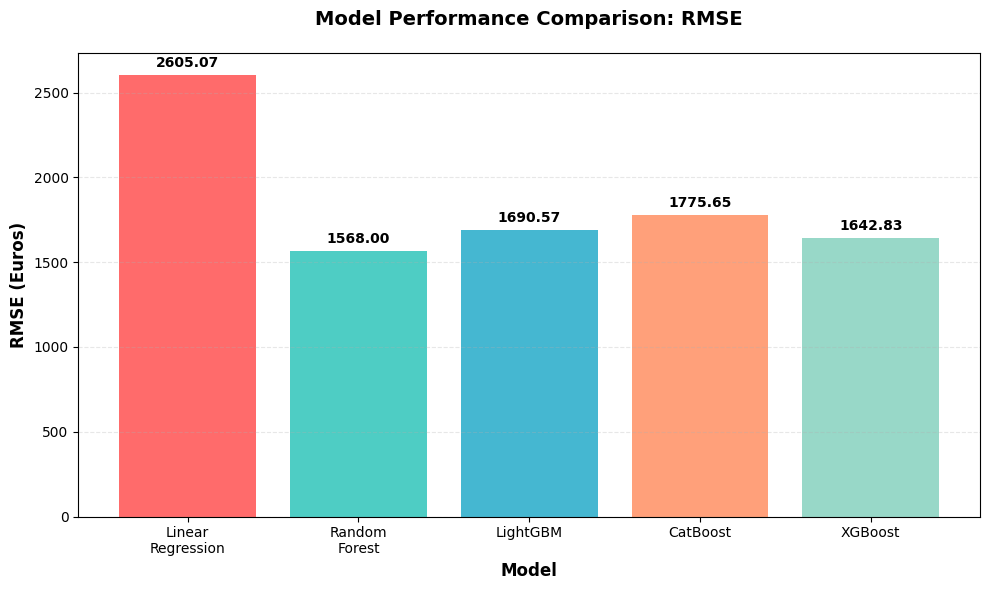


Lower RMSE = Better accuracy (predictions closer to actual prices)


In [26]:
# Visualization: RMSE Comparison

# Create bar chart comparing RMSE across models
models = ['Linear\nRegression', 'Random\nForest', 'LightGBM', 'CatBoost', 'XGBoost']
rmse_values = [lr_rmse, rf_final_rmse, lgb_final_rmse, cb_final_rmse, xgb_final_rmse]

# Create figure
plt.figure(figsize=(10, 6))
bars = plt.bar(models, rmse_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'])

# Add value labels on top of bars
for i, (bar, value) in enumerate(zip(bars, rmse_values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
        f'{value:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Formatting
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('RMSE (Euros)', fontsize=12, fontweight='bold')
plt.title('Model Performance Comparison: RMSE', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

# Show plot
plt.show()

print("\nLower RMSE = Better accuracy (predictions closer to actual prices)")

## Conclusions and Recommendation

### Model Performance Analysis

All gradient boosting models (LightGBM, CatBoost, XGBoost) and Random Forest significantly outperformed the Linear Regression baseline, confirming that tree-based algorithms are well-suited for this car pricing prediction task. Random Forest achieved the best RMSE of 1568.00, meaning predictions are off by approximately €1,568 on average. XGBoost (1642.83) came in second, followed by LightGBM (1690.57) and CatBoost (1775.65).

### Speed Trade-offs

Training time varied dramatically across models. LightGBM trained in just 5.05 seconds, making it 43 times faster than Random Forest (217.09 seconds) and 44 times faster than XGBoost (223.19 seconds). This difference becomes critical for a production application that needs regular model updates. For prediction speed, all models perform adequately, with CatBoost being fastest at 0.04 seconds per prediction.

### Recommendation for Rusty Bargain

I recommend Random Forest as the optimal model for Rusty Bargain's car pricing application. While it has a longer training time, it offers the best accuracy and reliable predictions:

- **Quality**: RMSE of 1568.00 (best among all models)
- **Prediction Speed**: 1.07 seconds (acceptable for real-time app usage)
- **Training Time**: 217.09 seconds (manageable for scheduled retraining)

However, if Rusty Bargain prioritizes fast retraining with minimal accuracy loss, LightGBM is an excellent alternative — its RMSE of 1690.57 is only €122 worse than Random Forest, but it trains 43 times faster. For a production system that needs frequent model updates with new data, LightGBM may be the more practical choice. For maximum accuracy, Random Forest is the clear winner.